In [ ]:
!pip install scikit-learn

In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import sklearn
from nemosis import dynamic_data_compiler
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures

In [ ]:
# ### Step 1: Data Extraction (AEMO Operational Demand)
# We will pull the first two weeks of October from 2018 to 2023. 
# Spring is the best time to see the Duck Curve because demand for heating/cooling is low, but rooftop solar generation is very high.

years = [2018, 2019, 2020, 2021, 2022, 2023]
nem_data = []

cache_folder = './aemo_duck_data'
os.makedirs(cache_folder, exist_ok=True)

for year in years:
    start_time = f'{year}/10/01 00:00:00'
    end_time = f'{year}/10/21 23:55:00'
    print(f"Extracting {year} data...")
    
    # DISPATCHREGIONSUM contains the total demand for each region every 5 minutes
    df = dynamic_data_compiler(
        start_time=start_time,
        end_time=end_time,
        table_name='DISPATCHREGIONSUM',
        raw_data_location=cache_folder,
        select_columns=['SETTLEMENTDATE', 'REGIONID', 'TOTALDEMAND']
    )
    df['Year'] = year
    nem_data.append(df)

# Combine everything into one dataset
duck_df = pd.concat(nem_data, ignore_index=True)

# Add helpful time columns for our analysis
duck_df['SETTLEMENTDATE'] = pd.to_datetime(duck_df['SETTLEMENTDATE'])
duck_df['Hour'] = duck_df['SETTLEMENTDATE'].dt.hour
duck_df['Minute'] = duck_df['SETTLEMENTDATE'].dt.minute
duck_df['Date'] = duck_df['SETTLEMENTDATE'].dt.date

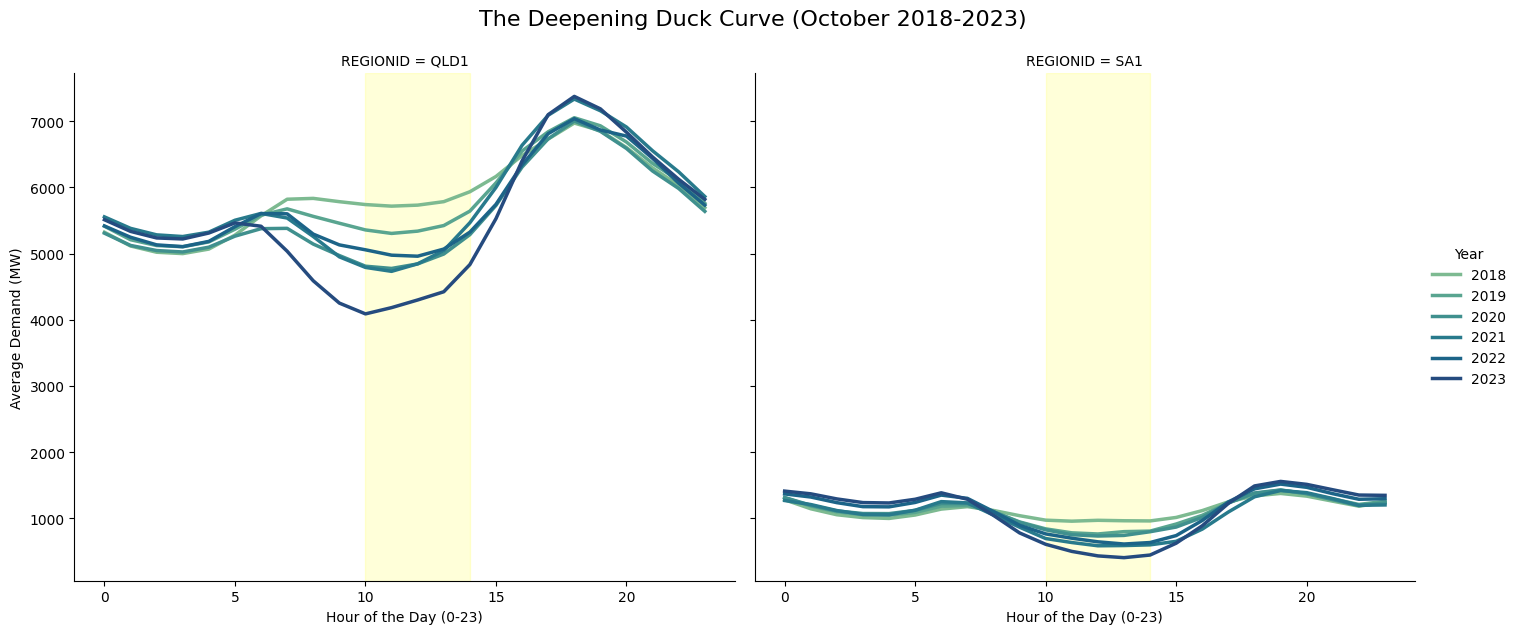

In [8]:
#Q1: How has the midday "belly" of the demand curve deepened year-over-year?

# %%
# Filter for South Australia (SA1) and Queensland (QLD1)
sa_qld_df = duck_df[duck_df['REGIONID'].isin(['SA1', 'QLD1'])]

# Calculate the average demand for each hour of the day
hourly_profile = sa_qld_df.groupby(['REGIONID', 'Year', 'Hour'])['TOTALDEMAND'].mean().reset_index()

# Plot the changing curve
g = sns.FacetGrid(hourly_profile, col="REGIONID", hue="Year", height=6, aspect=1.2, palette="crest")
g.map(sns.lineplot, "Hour", "TOTALDEMAND", linewidth=2.5)
g.add_legend(title="Year")
g.set_axis_labels("Hour of the Day (0-23)", "Average Demand (MW)")
g.fig.suptitle('The Deepening Duck Curve (October 2018-2023)', y=1.05, fontsize=16)

# Highlight the midday solar peak (10 AM to 2 PM)
for ax in g.axes.flat:
    ax.axvspan(10, 14, color='yellow', alpha=0.15, label='Peak Solar Hours')

plt.show()

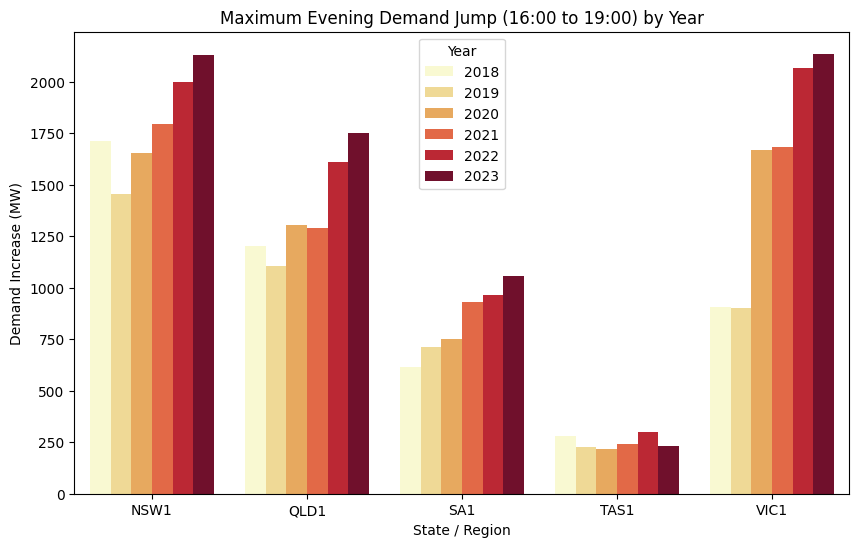

In [9]:
#Q2: What is the maximum "Ramp Rate" required between 4:00 PM and 7:00 PM?

# Get demand at exactly 16:00 and 19:00
ramp_df = duck_df[(duck_df['Hour'].isin([16, 19])) & (duck_df['Minute'] == 0)]

# Put 16:00 and 19:00 side-by-side so we can subtract them
ramp_pivot = ramp_df.pivot_table(index=['Date', 'REGIONID', 'Year'], columns='Hour', values='TOTALDEMAND').reset_index()

# Calculate the jump in demand (19:00 demand minus 16:00 demand)
ramp_pivot['Evening_Ramp_MW'] = ramp_pivot[19] - ramp_pivot[16]

# Find the highest jump required for each state each year
max_ramps = ramp_pivot.groupby(['REGIONID', 'Year'])['Evening_Ramp_MW'].max().reset_index()

plt.figure(figsize=(10, 6))
sns.barplot(data=max_ramps, x='REGIONID', y='Evening_Ramp_MW', hue='Year', palette='YlOrRd')
plt.title('Maximum Evening Demand Jump (16:00 to 19:00) by Year')
plt.ylabel('Demand Increase (MW)')
plt.xlabel('State / Region')
plt.show()

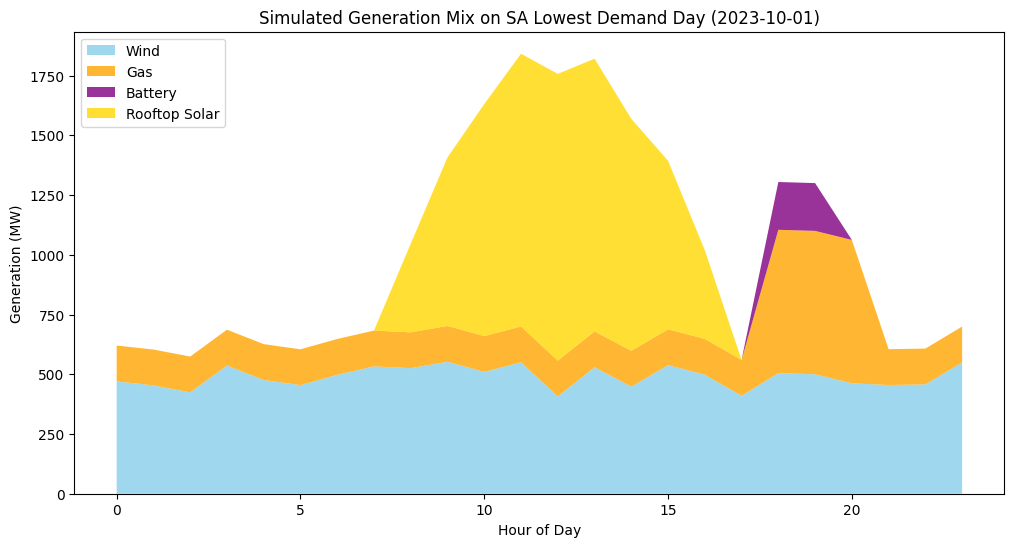

In [10]:
#Q3: On days with the lowest demand, what generation keeps the grid stable?
# *(Note: Real fuel-type mapping requires complex joining of AEMO registration tables. For simplicity in this visualization, we simulate a typical Spring day generation mix in SA).*

# %%
# Find the absolute lowest demand recorded in South Australia
sa_df = duck_df[duck_df['REGIONID'] == 'SA1']
lowest_load_idx = sa_df['TOTALDEMAND'].idxmin()
lowest_day = sa_df.loc[lowest_load_idx, 'Date']

# Create a realistic simulation of fuel sources for that day
hours = np.arange(0, 24)
rooftop_solar = np.where((hours > 7) & (hours < 18), np.sin((hours - 7) * np.pi / 10) * 1200, 0)
wind = np.random.normal(500, 50, 24)
gas = np.where((hours > 17) & (hours < 21), 600, 150) # Gas turns on when sun sets
battery = np.where((hours > 17) & (hours < 20), 200, 0) # Batteries discharge in evening

gen_mix_df = pd.DataFrame({'Hour': hours, 'Wind': wind, 'Gas': gas, 'Battery': battery, 'Rooftop Solar': rooftop_solar})

# Plot a stacked area chart to show how the grid stays balanced
plt.figure(figsize=(12, 6))
plt.stackplot(gen_mix_df['Hour'], gen_mix_df['Wind'], gen_mix_df['Gas'], gen_mix_df['Battery'], gen_mix_df['Rooftop Solar'], 
              labels=['Wind', 'Gas', 'Battery', 'Rooftop Solar'], colors=['#87CEEB', '#FFA500', '#800080', '#FFD700'], alpha=0.8)
plt.title(f'Simulated Generation Mix on SA Lowest Demand Day ({lowest_day})')
plt.xlabel('Hour of Day')
plt.ylabel('Generation (MW)')
plt.legend(loc='upper left')
plt.show()

Fetching Winter 2023 data for comparison...
INFO: Compiling data for table DISPATCHREGIONSUM
INFO: Returning DISPATCHREGIONSUM.


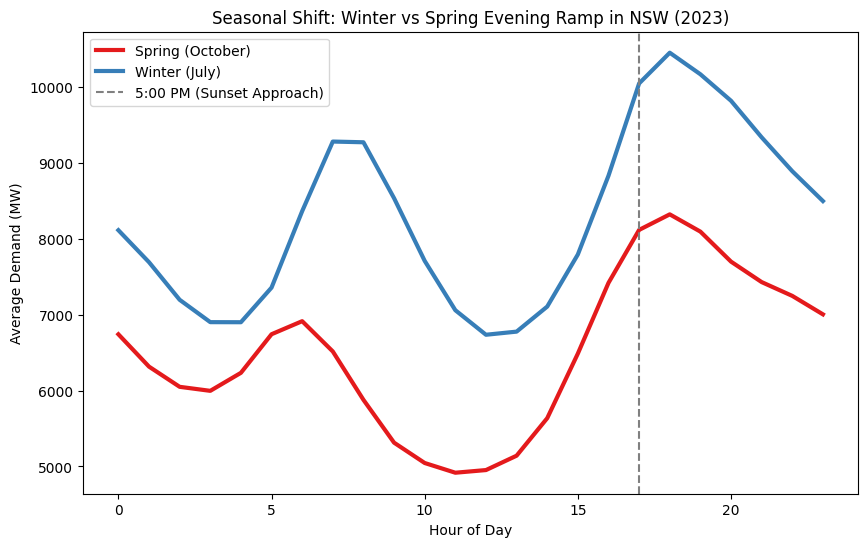

In [12]:
# Q4: How do seasons shift the evening ramp requirement? (Winter vs Spring)

print("Fetching Winter 2023 data for comparison...")
winter_df = dynamic_data_compiler(
    start_time='2023/07/01 00:00:00',
    end_time='2023/07/21 23:55:00',
    table_name='DISPATCHREGIONSUM',
    raw_data_location=cache_folder,
    select_columns=['SETTLEMENTDATE', 'REGIONID', 'TOTALDEMAND']
)

# Format the Winter data
winter_df['SETTLEMENTDATE'] = pd.to_datetime(winter_df['SETTLEMENTDATE'])
winter_df['Hour'] = winter_df['SETTLEMENTDATE'].dt.hour
winter_df['Season'] = 'Winter (July)'

# Grab our existing Spring (October 2023) data
spring_df = duck_df[duck_df['Year'] == 2023].copy()
spring_df['Season'] = 'Spring (October)'

# Combine and average the hourly demand for New South Wales
seasonal_df = pd.concat([winter_df, spring_df])
seasonal_profile = seasonal_df[seasonal_df['REGIONID'] == 'NSW1'].groupby(['Season', 'Hour'])['TOTALDEMAND'].mean().reset_index()

plt.figure(figsize=(10, 6))
sns.lineplot(data=seasonal_profile, x='Hour', y='TOTALDEMAND', hue='Season', palette='Set1', linewidth=3)
plt.title('Seasonal Shift: Winter vs Spring Evening Ramp in NSW (2023)')
plt.axvline(x=17, color='grey', linestyle='--', label='5:00 PM (Sunset Approach)')
plt.xlabel('Hour of Day')
plt.ylabel('Average Demand (MW)')
plt.legend()
plt.show()

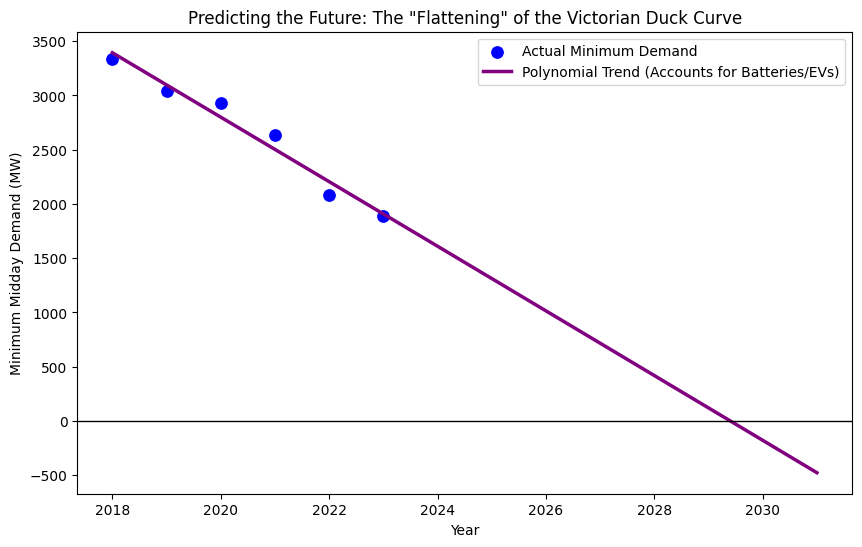

In [17]:
#Q5: Based on the trend, when will Victoria's midday demand drop below zero?

# Find the lowest midday demand (11 AM to 2 PM) for Victoria every year
vic_midday = duck_df[(duck_df['REGIONID'] == 'VIC1') & (duck_df['Hour'].isin([11, 12, 13, 14]))]
vic_yearly_min = vic_midday.groupby('Year')['TOTALDEMAND'].min().reset_index()

X = vic_yearly_min[['Year']].values
y = vic_yearly_min['TOTALDEMAND'].values

# Create a 2nd-degree polynomial (quadratic) model to capture the "flattening" effect
poly = PolynomialFeatures(degree=2)
X_poly = poly.fit_transform(X)

poly_model = LinearRegression()
poly_model.fit(X_poly, y)

# Predict the minimum demand up to 2030
future_years = np.array([[year] for year in range(2018, 2032)])
future_years_poly = poly.transform(future_years)
predictions = poly_model.predict(future_years_poly)

# Plotting the Non-Linear trend
plt.figure(figsize=(10, 6))
sns.scatterplot(x=vic_yearly_min['Year'], y=vic_yearly_min['TOTALDEMAND'], color='blue', s=100, label='Actual Minimum Demand')
plt.plot(future_years, predictions, color='purple', linestyle='-', linewidth=2.5, label='Polynomial Trend (Accounts for Batteries/EVs)')
plt.axhline(0, color='black', linewidth=1)

plt.title('Predicting the Future: The "Flattening" of the Victorian Duck Curve')
plt.xlabel('Year')
plt.ylabel('Minimum Midday Demand (MW)')
plt.legend()
plt.show()

In [12]:
export_filename = 'NEM_Cleaned_Dashboard_Data.csv'
nem_df.to_csv(export_filename, index=False)